In [87]:
%load_ext autoreload
%autoreload 2

import os
os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] = "false"
assert os.environ["XLA_PYTHON_CLIENT_PREALLOCATE"] == "false"

import sys
sys.path.append('../')
sys.path.append('../../')

import ATLAS

import json, pickle
from glob import glob
from tqdm import tqdm

import numpy as np
from matplotlib import pyplot as plt

from functools import partial
import jax.numpy as jnp
import jax.random as jrandom

from ATLAS.utils import jit

import numpyro
import numpyro.distributions as dist

sim_path = '../../datasets/sim_NG15_01'

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [88]:
from ATLAS.pulsar import load_pulsars
from ATLAS.data import PTA_Data

npsrs = 10

par = sorted(glob(sim_path+'/par/*.par'))[:npsrs]
tim = sorted(glob(sim_path+'/tim/*.tim'))[:npsrs]

psrs = load_pulsars(par, tim, use_enterprise=True)

data = PTA_Data(psrs, fixed_res = False, marg_timing = False, 
                diag_white_cov = False, linear_timing = True)


Loading pulsars...:   0%|          | 0/10 [00:00<?, ?it/s]

JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.JAX 64-bit mode automatically enabled successfully.JAX 64-bit mode automatically enabled successfully.


JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.
JAX 64-bit mode automatically enabled successfully.


libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
libstempo not installed. PINT or libstempo are required to use par and tim files.
Loading pulsars...: 100%|██████████| 10/10 [00:27<00:00,  2.77s/it]


In [89]:

from ATLAS.psd_functions import powerlaw, free_spectrum, hd_orf
from ATLAS.signals.factorized.base import Red, SuperSignal
from ATLAS.signals.correlated.base import Correlated
from ATLAS.nMatrix.base import WhiteCov
from ATLAS.signals import signals_utils as sutils
import ATLAS.utils as atlas_utils
import ATLAS.signals.factorized.utils as unc_utils
import ATLAS.signals.correlated.utils as cor_utils

raw_res = jnp.concat(data.raw_residuals)

## White Noise Model
wn_model = WhiteCov(data = data, stabelize_TNT = True)
wn_lower_bound, wn_upper_bound = wn_model.get_prior_bounds() #white noise prior bounds
## Red Noise Model
non_gwb_nfreqs = 30
gwb_nfreqs = 14
sig_unc = Red(name='unc',
            psd_function = partial(powerlaw),
            nfreqs=non_gwb_nfreqs,
            lower_bound_psd = jnp.array([-18, 0.]),
            upper_bound_psd = jnp.array([-11, 7.0]),
            data = data,
            use_pulsar_tspan = False)
sig_cor = Correlated(name='cor',
            psd_function = partial(powerlaw),
            orf_function = hd_orf,
            nfreqs=gwb_nfreqs,
            lower_bound_psd = jnp.array([-18., 0.]),
            upper_bound_psd = jnp.array([-11., 1.]),
            data = data)
sig = SuperSignal(signal_list = [sig_unc, sig_cor],
                signal_combination_string = "cor + unc -> unc",
                data=data)


Construncting the white noise cov matrix for B1855+09:   0%|          | 0/10 [00:00<?, ?it/s]

Construncting the white noise cov matrix for J0557+1551: 100%|██████████| 10/10 [00:01<00:00,  8.09it/s]


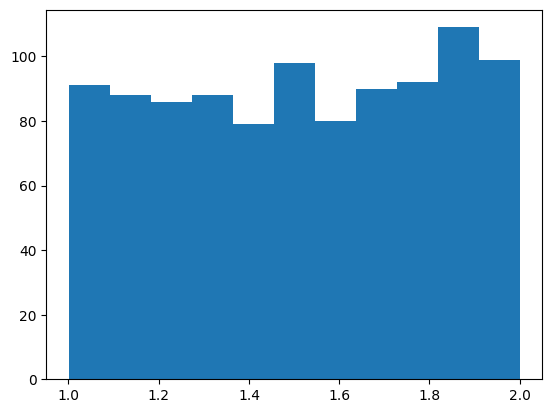

In [109]:

u = dist.Uniform(1,2).expand([1000]).sample(jrandom.PRNGKey(7))
plt.hist(u, bins='auto');

In [ ]:
dist.Uniform(0,1).expand([3])
u = [dist.Uniform(0,1), dist.Uniform(0,2), dist.Uniform(0,3)]
numpyro.sample('u', u)


TypeError: Invalid type for 'fn': expected an instance of numpyro.distributions.Distribution, funsor.Funsor or tensorflow_probability.distributions.Distribution, but received list. If you're using funsor or tensorflow_probability, make sure they are correctly installed.

In [150]:
# Custom timing model: Split the timing model matrix into binary and non-binary
# r = dt - Me_{non-binary} - Me_{binary}

binary_priors = {
    'PB':       dist.Uniform(0.05, 500),        # Orbital period (days)
    'PBDOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of orbital period
    'A1':       dist.Uniform(0, 150),           # Projected semi-major axis (light-seconds)
    'A1DOT':    dist.Uniform(-1e-10, 1e-10),    # Time derivative of A1
    '_DT0':     dist.Uniform(-1, 1),            # delta of T0 (MJD)
    'T0':       None, # Use _DT0 to derive      # Epoch of periastron passage (MJD)
    '_DTASC':   dist.Uniform(-1, 1),            # delta of TASC (MJD)
    'TASC':     None, # Use _DTASC to derive    # Epoch of ascending node passage (MJD)
    'ECC':      dist.Uniform(0, 1),             # Orbital eccentricity
    'EDOT':     dist.Uniform(-1e-10, 0),        # Time derivative of eccentricity
    'OM':       dist.Uniform(-360, 360),        # Longitude of periastron (deg)
    'OMDOT':    dist.Uniform(-3, 3),            # Time derivative of OM
    'EPS1':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*sin(omega)
    'EPS2':     dist.Uniform(-1, 1),            # Laplace-Lagrange parameter e*cos(omega)
    '_COSI':    dist.Uniform(0, 1),             # cos(inclination) [Used to derive SINI]
    'SINI':     None, # Use _COSI to derive     # sin(inclination)
    'M2':       dist.TruncatedNormal( loc=0.214, scale=0.25, 
                low=0, high=1),                 # Companion mass (solar masses)
    'KIN':      dist.Uniform(0, 360),           # Inclination angle (deg), used by DDK
    'KOM':      dist.Uniform(-180, 180),        # Longitude of ascending node (deg), used by DDK
    'H3':       dist.Uniform(-1e-6, 1e-6),      # Orthometric Shapiro delay amplitude
    'FB0':      dist.Uniform(0, 1),             # Orbital frequency and derivatives (ELL1)
    'FB1':      dist.Uniform(-1e-15, 1e-15),     
    'FB2':      dist.Uniform(-1e-15, 1e-15),
    'FB3':      dist.Uniform(-1e-15, 1e-15),
    'FB4':      dist.Uniform(-1e-15, 1e-15),
    'FB5':      dist.Uniform(-1e-15, 1e-15),
}

class CustomTimingModel:
    def __init__(self, psrs, improper_z=1e5):
        self.psrs = psrs
        self.improper_z = improper_z
        # index of pulsars with binaries
        self.has_binary = np.where(['A1' in p.Mmat_labels for p in psrs])[0] 

        # Residuals
        self.residuals = [p.residuals for p in psrs]
        self.concat_residuals = jnp.concatenate(self.residuals)

        self.Mb, self.Mb_labels = [], []
        self.Mo, self.Mo_labels = [], []
        
        self.sigma_o = [] # Uncertainties of non-binary parameters
        self.hat_theta_b = [] # Fit binary parameter values
        
        for i,psr in enumerate(psrs):
            M,label = psr.Mmat, np.array(psr.Mmat_labels)

            is_b_param = np.array([l in binary_priors.keys() for l in label])
            is_o_param = ~is_b_param

            self.Mb.append(M[:,is_b_param])
            self.Mb_labels.append(psr.name+'_'+label[is_b_param])

            self.Mo.append(M[:,is_o_param])
            self.Mo_labels.append(psr.name+'_'+label[is_o_param])

            s = jnp.insert(psr.fit_param_uncertainties, 0, 1.0) # Add offset uncertainty
            self.sigma_o.append(s[is_o_param])

            v = psr.fit_param_values[is_b_param[1:]] # 1 to ignore offset
            self.hat_theta_b.append(v)

        self.concat_sigma_o = jnp.concatenate(self.sigma_o)
        self.concat_Mo_labels = np.concatenate(self.Mo_labels)

        # We need ways to convert concatenated epsilons and theta_binaries into
        # blocks per pulsar.
        split = np.cumsum(np.array([Mo.shape[1] for Mo in self.Mo]))[:-1]
        self._nonbinary_split = split.tolist()

    def sample_epsilon_b(self):
        all_epsilon_b = []
        for i, Mb_labels in enumerate(self.Mb_labels): # For each pulsar
            psr_epsilon_b = []
            for j, label in enumerate(Mb_labels): # For each label
                # Special cases
                if 'T0' in label or 'TASC' in label:
                    # T0 and TASC should be +-1 day
                    dv = numpyro.sample(label+'_delta', dist.Uniform(-1.0, 1.0))
                    # Already in dv, no need to tranform into deltas
                    psr_epsilon_b.append(dv)
                elif 'SINI' in label:
                    # Sample in COSI instead, then transform to SINI
                    cosi = numpyro.sample(label[:-4]+'COSI', dist.Uniform(0, 1.0))
                    v = jnp.sin(jnp.arccos(cosi))
                    numpyro.deterministic(label, v)
                    dv = v - self.hat_theta_b[i][j]
                    psr_epsilon_b.append(dv)
                else:
                    # Default case uses a pre-defined prior
                    v = numpyro.sample(label, binary_priors[label.split('_')[-1]])
                    dv = v - self.hat_theta_b[i][j]
                    psr_epsilon_b.append(dv)

            all_epsilon_b.append(jnp.array(psr_epsilon_b))
        return all_epsilon_b

    def sample_epsilon_o(self):
        epsilon_o = numpyro.sample('epsilon_o', dist.Normal(0, self.concat_sigma_o*self.improper_z))
        # Split into per-pulsar blocks
        return jnp.split(epsilon_o, self._nonbinary_split) # [npsr, n_o]

    @jit(static_argnums=(0,))
    def get_r_stochastic(self, epsilon_b, epsilon_o):
        all_dr = []
        for i in range(len(self.psrs)):
            dr = self.Mb[i] @ epsilon_b[i] + self.Mo[i] @ epsilon_o[i]
            all_dr.append(dr)
        r_stochastic = self.concat_residuals - jnp.concatenate(all_dr)
        return r_stochastic


    

TM = CustomTimingModel(psrs)



In [151]:
epsilon_b = [jnp.zeros(Mb.shape[1]) for Mb in TM.Mb]
epsilon_o = [jnp.zeros(Mo.shape[1]) for Mo in TM.Mo]
r = TM.get_r_stochastic(epsilon_b, epsilon_o)
np.sum(r - TM.concat_residuals)

Array(0., dtype=float64)

In [152]:
%timeit TM.get_r_stochastic(epsilon_b, epsilon_o)

184 μs ± 24.5 ns per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [153]:
import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

from ATLAS.samplers.canetoadracing import MultiHMCGibbs


def model():
    ######################################## Timing Model ########################################
    epsilon_b = TM.sample_epsilon_b()
    epsilon_o = TM.sample_epsilon_o()
    r_stoc = TM.get_r_stochastic(epsilon_b, epsilon_o)

    ######################################## White Noise ########################################
    # Declare the variables in the model
    theta_wn = numpyro.sample('theta_wn', dist.Uniform(wn_lower_bound, wn_upper_bound))
    helpers_now = sig.get_helpers(reff = r_stoc, white_noise_params=theta_wn)
    
    ######################################## Red Noise ########################################
    # Declare the variables in the model
    xs = numpyro.sample('xs', dist.Uniform(sig.model.lower_prior_lim_all, 
                                           sig.model.upper_prior_lim_all)) #PSD params
    z_a = numpyro.sample('z_a', dist.Normal(0, 1).expand((sig.npsrs, sig.nmodes))) #the reparam coefficients
    # evaluate the posterior
    lprob, coeff = sig.lnposterior_reparam(helpers = helpers_now, red_params = xs, z = z_a)
    numpyro.factor('lnpost', lprob + 0.5 * jnp.sum(z_a**2))
    numpyro.deterministic('coeff', coeff)
    

In [154]:

kernel = NUTS(
    model=model,
    max_tree_depth = 8,
    dense_mass = False ,
)
mcmc = MCMC(
    sampler=kernel,
    num_warmup=1000,
    num_samples=4000,
    num_chains=1)

mcmc.run(jrandom.key(170817))

TypeError: broadcast_in_dim shape must have every element be nonnegative, got (-122, 10).